In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
NUM_LED = 273
led_pos = 10

x = np.linspace(0, 1, NUM_LED)
offset = 0.3
a = 1.0 - offset
b, c = 0.5, led_pos/NUM_LED

gauss = a*np.exp(-(x-b)**2/(2*c**2)) + offset

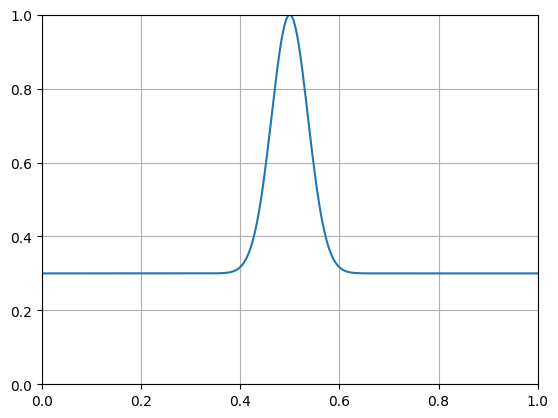

In [19]:
plt.plot(x, gauss)
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()
plt.show()

In [35]:
mask = np.where(gauss > offset+0.03)[0]

zip_gauss = gauss[mask]
print(len(zip_gauss))

(zip_gauss*255).astype(int)

51


array([ 84,  86,  88,  92,  95, 100, 105, 111, 118, 125, 133, 143, 152,
       162, 173, 184, 195, 205, 215, 225, 233, 241, 247, 251, 254, 255,
       254, 251, 247, 241, 233, 225, 215, 205, 195, 184, 173, 162, 152,
       143, 133, 125, 118, 111, 105, 100,  95,  92,  88,  86,  84])

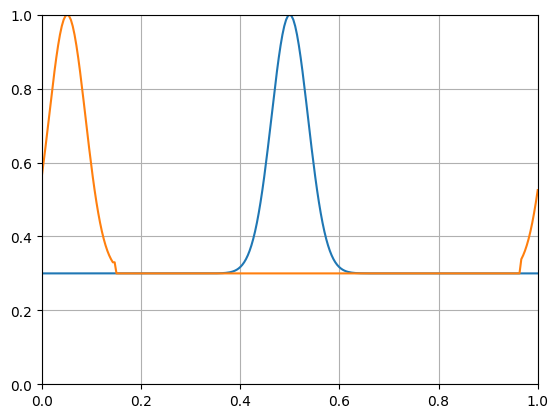

In [36]:
# x0 = 124
# xc = 136
# x1 = 148
d2 = len(zip_gauss)

x0 = 0
xc = 25
x1 = d2-1

c_new = 15

dist = xc - c_new
a_new = (x0-dist) % NUM_LED
b_new = (x1-dist) % NUM_LED

gauss_map = np.zeros_like(gauss)

if a_new < b_new:
    i_count = 0
    sliced = False
else:
    i_count = d2 - b_new
    sliced = True

if not sliced:
    for i in range(NUM_LED):
        if i >= a_new and i <= b_new:
            gauss_map[i] = zip_gauss[i_count]
            i_count += 1
        else:
            gauss_map[i] = offset
else:
    for i in range(NUM_LED):
        if i <= b_new or i >= a_new:
            gauss_map[i] = zip_gauss[i_count]
            i_count = (i_count + 1) % d2
        else:
            gauss_map[i] = offset

plt.plot(x, gauss)
plt.plot(x, gauss_map)
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()
plt.show()